In [113]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [114]:
print(f"Pytorch version: {torch.__version__}")

Pytorch version: 2.9.1+cu126


In [115]:
print(f"Cuda version: {torchvision.__version__}")

Cuda version: 0.24.1+cu126


In [116]:
train_data=torchvision.datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data=torchvision.datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
    
)

In [117]:
len(train_data.data),len(train_data.targets),len(test_data.data),len(test_data.targets)

(60000, 60000, 10000, 10000)

In [118]:
class_names=train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [119]:
image,label=train_data[0]
print(f"Image shape: {image.shape}")

Image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

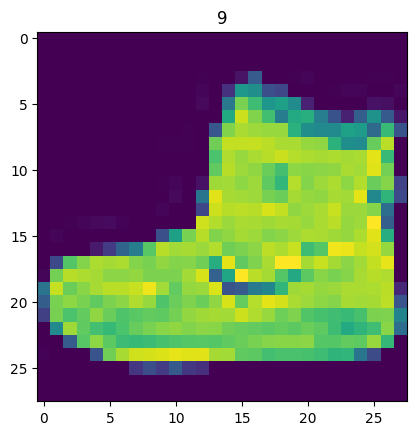

In [120]:
plt.imshow(image.squeeze())
plt.title(label)

In [121]:
from torch.utils.data import DataLoader


In [122]:
BATCH_SIZE=32

train_dataloader=DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)
test_dataloader=DataLoader(
    test_data,
    batch_size=BATCH_SIZE
)

In [123]:
class FashionMnistModel(nn.Module):
    def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
        super().__init__()
        self.block1=nn.Sequential(
            nn.Conv2d( in_channels=input_shape,
                      out_channels=16,
                      kernel_size=3,
                      stride=1,
                      padding=0 ),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(in_channels=16,
                      out_channels=32,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )
        
        self.block2=nn.Sequential(
            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier=nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=64*6*6,
                      out_features=output_shape)
        )
        
    def forward(self,x:torch.Tensor):
        x=self.block1(x)
        x=self.block2(x)
        x=self.classifier(x)
        
        return x 
    
    

       

In [124]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [125]:
model_0=FashionMnistModel(input_shape=1,
                          hidden_units=16,
                          output_shape=len(class_names)).to(device)

In [126]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.1)

In [127]:
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [128]:
def train_step(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               accuracy_fn,
               device:torch.device=device
               ):
    train_loss,train_acc=0,0
    model.to(device)
    model.train()
    
    for batch, (X,y) in enumerate (data_loader):
        X,y=X.to(device),y.to(device)
        
        y_pred=model(X)
        
        loss=loss_fn(y_pred,y)
        train_loss += loss
        
        train_acc += accuracy_fn(y_true=y,y_pred=y_pred.argmax(dim=1))
        
        
        optimizer.zero_grad()
        
        loss.backward()
        
        optimizer.step()
        
        
    train_loss /= len(data_loader)
    
    train_acc /= len(data_loader)
    
    print(f"Train loss: {train_loss:.5f} Train accuracy: {train_acc: .2f}% ") 

In [129]:
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device=device):
    
    test_loss,test_acc = 0, 0
    
    model.to(device)
    model.eval
    
    with torch.inference_mode():
        for X,y in data_loader:
            X,y= X.to(device), y.to(device)
            
            test_pred=model(X)
            
            test_loss += loss_fn(test_pred,y)
            
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))
            
            
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        
        
        print(f"Test Loss: {test_loss :.5f} Test Accuracy: {test_acc : .2f}%\n")
        
    

In [130]:
from timeit import default_timer as timer

def print_train_time(start:float, end:float,device:torch.device=None):
    total_time=end-start
    print(f"train time on {device}: {total_time: .3f} seconds")
    return total_time

In [131]:
from tqdm.auto import tqdm
from helper_functions import accuracy_fn
torch.manual_seed=42

train_time_start_model_0=timer()

epochs=20

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------------")
    
    train_step(data_loader=train_dataloader,
               model=model_0,
               loss_fn=loss_fn,
               optimizer=optimizer,
               accuracy_fn=accuracy_fn,
               device=device)
    
    test_step(data_loader=test_dataloader,
              model=model_0,
              loss_fn=loss_fn,
              accuracy_fn=accuracy_fn,
              device=device)
    
    
train_time_end_model_0=timer()

total_train_time_model_0=print_train_time(start=train_time_start_model_0,
                                          end=train_time_end_model_0,
                                          device=device)
    

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 0
-------------
Train loss: 0.45220 Train accuracy:  84.79% 


  5%|▌         | 1/20 [00:21<06:51, 21.64s/it]

Test Loss: 0.32352 Test Accuracy:  88.27%

Epoch: 1
-------------
Train loss: 0.26246 Train accuracy:  90.46% 


 10%|█         | 2/20 [00:46<07:02, 23.48s/it]

...

Test Loss: 0.35561 Test Accuracy:  91.39%

Epoch: 18
-------------
Train loss: 0.03050 Train accuracy:  98.94% 


 95%|█████████▌| 19/20 [07:16<00:24, 24.10s/it]

Test Loss: 0.34347 Test Accuracy:  91.76%

Epoch: 19
-------------
Train loss: 0.02877 Train accuracy:  99.02% 


100%|██████████| 20/20 [07:38<00:00, 22.91s/it]

Test Loss: 0.36458 Test Accuracy:  91.52%

train time on cuda:  458.288 seconds
